# Final Test Evaluation

The model configuration was fixed during development. This notebook evaluates it once on the stratified test holdout, which was excluded from feature selection, training, tuning, threshold selection, and final-model selection.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
ROOT = Path.cwd().parent
if not (ROOT / 'data' / 'raw' / 'wind_turbine_detection.csv').exists():
    ROOT = Path.cwd() / 'PROJECT 1'
df = pd.read_csv(ROOT / 'data' / 'raw' / 'wind_turbine_detection.csv')
predictors = [column for column in df.select_dtypes(include='number').columns if column != 'failure']
X, y = df[predictors], df['failure']

# This split matches the development workflow. X_test is not used until the final evaluation cell.
X_development, X_test, y_development, y_test = train_test_split(X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_validation, y_train, y_validation = train_test_split(X_development, y_development, test_size=.25, stratify=y_development, random_state=RANDOM_STATE)
display(Markdown(f'Prepared {len(X_development):,} development records and **{len(X_test):,} completely held-out test records**. The test predictors and labels are not used above.'))

Prepared 105,408 development records and **26,352 completely held-out test records**. The test predictors and labels are not used above.

In [2]:
# Pre-specified final model: configuration fixed before test evaluation.
def build_final_model(class_weight_ratio):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=.05, min_child_weight=3, gamma=.1, subsample=.85, colsample_bytree=.85, reg_alpha=.01, reg_lambda=1.0, scale_pos_weight=class_weight_ratio, eval_metric='logloss', n_jobs=1, random_state=RANDOM_STATE)),
    ])

def classification_metrics(y_true, predictions, dataset):
    return pd.DataFrame([{
        'dataset': dataset,
        'accuracy': accuracy_score(y_true, predictions),
        'precision': precision_score(y_true, predictions, pos_label=1, zero_division=0),
        'recall': recall_score(y_true, predictions, pos_label=1, zero_division=0),
        'f1': f1_score(y_true, predictions, pos_label=1, zero_division=0),
    }])

# Development validation estimate, retained only for later consistency comparison.
development_weight = (y_train == 0).sum() / (y_train == 1).sum()
validation_model = build_final_model(development_weight)
validation_model.fit(X_train, y_train)
validation_predictions = validation_model.predict(X_validation)
validation_metrics = classification_metrics(y_validation, validation_predictions, 'validation')
display(Markdown('The configuration above was fixed before the test is scored; no threshold or parameter will be changed after viewing test metrics.'))

The configuration above was fixed before the test is scored; no threshold or parameter will be changed after viewing test metrics.

In [3]:
# Final fit on all development data, followed by exactly one test evaluation.
final_weight = (y_development == 0).sum() / (y_development == 1).sum()
final_model = build_final_model(final_weight)
final_model.fit(X_development, y_development)
test_predictions = final_model.predict(X_test)
test_metrics = classification_metrics(y_test, test_predictions, 'unseen_test')
performance_comparison = pd.concat([validation_metrics, test_metrics], ignore_index=True)
display(Markdown('## Final validation and unseen-test performance'))
display(performance_comparison.style.format({'accuracy': '{:.3f}', 'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}'}))
display(Markdown(f'**Primary result:** unseen-test Recall for fault class `1` is **{test_metrics.loc[0].recall:.3f}**.'))

## Final validation and unseen-test performance

,dataset,accuracy,precision,recall,f1
0,validation,0.989,0.740,0.994,0.848
1,unseen_test,0.989,0.733,0.990,0.842


**Primary result:** unseen-test Recall for fault class `1` is **0.990**.

## Unseen-test confusion matrix (positive class: fault = 1)

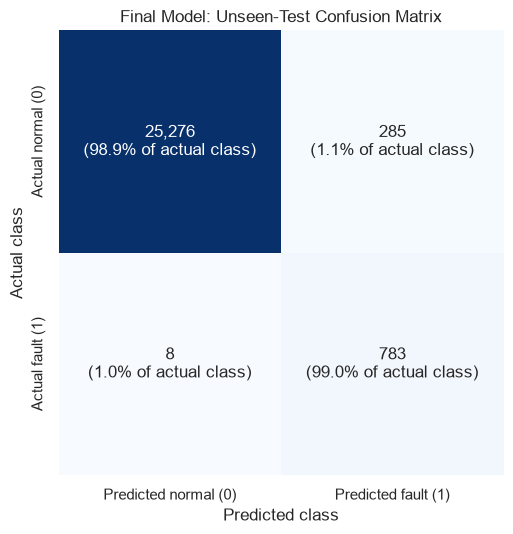

,outcome,count,meaning
0,True Negatives,25276,Normal records correctly left unflagged
1,False Positives,285,Normal records incorrectly flagged for inspection
2,False Negatives,8,Fault records missed by the model
3,True Positives,783,Fault records correctly detected


In [4]:
# Counts and row percentages make fault detection and missed faults explicit.
matrix = confusion_matrix(y_test, test_predictions, labels=[0, 1])
tn, fp, fn, tp = matrix.ravel()
row_pct = matrix / matrix.sum(axis=1, keepdims=True) * 100
annotations = np.array([[f'{count:,}\n({pct:.1f}% of actual class)' for count, pct in zip(count_row, pct_row)] for count_row, pct_row in zip(matrix, row_pct)])
display(Markdown('## Unseen-test confusion matrix (positive class: fault = 1)'))
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(matrix, annot=annotations, fmt='', cmap='Blues', cbar=False, square=True, ax=ax, xticklabels=['Predicted normal (0)', 'Predicted fault (1)'], yticklabels=['Actual normal (0)', 'Actual fault (1)'])
ax.set(title='Final Model: Unseen-Test Confusion Matrix', xlabel='Predicted class', ylabel='Actual class')
plt.tight_layout(); plt.show(); plt.close(fig)
confusion_breakdown = pd.DataFrame({'outcome': ['True Negatives', 'False Positives', 'False Negatives', 'True Positives'], 'count': [tn, fp, fn, tp], 'meaning': ['Normal records correctly left unflagged', 'Normal records incorrectly flagged for inspection', 'Fault records missed by the model', 'Fault records correctly detected']})
display(confusion_breakdown)

In [5]:
validation_row = validation_metrics.iloc[0]
test_row = test_metrics.iloc[0]
recall_change = test_row.recall - validation_row.recall
f1_change = test_row.f1 - validation_row.f1
interpretation = f"""## Business interpretation

- The model detected **{tp:,} of {tp + fn:,}** genuine fault observations, giving Recall of **{test_row.recall:.1%}**. This is the key measure for reducing missed drivetrain degradation.
- It missed **{fn:,}** fault observations (false negatives). Those are the cases most likely to remain in service without an early warning, so this residual risk requires operational review.
- It incorrectly flagged **{fp:,}** normal observations as faults (false positives). Precision of **{test_row.precision:.1%}** indicates the likely alert burden; analysts need enough capacity to review these alerts.
- Test Recall changed by **{recall_change:+.3f}** and F1 by **{f1_change:+.3f}** relative to validation. Similar validation and test metrics support useful generalisation, while a material drop would signal caution and further time/turbine-based validation.
- These one-time holdout results are the final estimate of expected real-world classification performance for this development dataset. Continue to monitor Recall, Precision, alert volume, and sensor drift after deployment.
"""
display(Markdown(interpretation))

## Business interpretation

- The model detected **783 of 791** genuine fault observations, giving Recall of **99.0%**. This is the key measure for reducing missed drivetrain degradation.
- It missed **8** fault observations (false negatives). Those are the cases most likely to remain in service without an early warning, so this residual risk requires operational review.
- It incorrectly flagged **285** normal observations as faults (false positives). Precision of **73.3%** indicates the likely alert burden; analysts need enough capacity to review these alerts.
- Test Recall changed by **-0.004** and F1 by **-0.006** relative to validation. Similar validation and test metrics support useful generalisation, while a material drop would signal caution and further time/turbine-based validation.
- These one-time holdout results are the final estimate of expected real-world classification performance for this development dataset. Continue to monitor Recall, Precision, alert volume, and sensor drift after deployment.


# Business Insights and Operational Recommendations

The classifier should operate as a decision-support capability for the operations centre and maintenance planners—not as an automatic shutdown mechanism. Its value comes from directing attention toward likely drivetrain degradation early enough to plan a safe intervention.

In [6]:
# Translate the final holdout results into an operational action plan.
test_recall = test_row.recall
test_precision = test_row.precision
test_f1 = test_row.f1

business_actions = f"""## What the model means for Aeolus Renewables

### 1. Use the model as a fleet-triage signal
The test Recall of **{test_recall:.1%}** means the model identifies that share of recorded drivetrain-fault observations. Surface high-risk turbines in a ranked daily operations-centre queue rather than requiring analysts to scan every SCADA channel across the fleet. Pair each alert with its leading sensor drivers, recent trend, turbine ID, and current operating state.

### 2. Protect against missed faults
The **{fn:,} false negatives** are the residual missed-fault risk. Keep existing catastrophic alarms and scheduled inspections in place as safety backstops. Add a second review trigger for turbines with rising drivetrain vibration, bearing/gearbox temperatures, FFT indicators, or oil particles even when the classifier score remains below the action threshold.

### 3. Make false alerts operationally manageable
Precision is **{test_precision:.1%}**, with **{fp:,} normal observations** incorrectly flagged in this held-out evaluation. Do not dispatch a technician for every alert. Use a tiered workflow: (a) remote analyst review and trend confirmation, (b) targeted inspection at the next practical visit, and (c) urgent maintenance planning only when a high score is corroborated by persistent deterioration or multiple related sensor signals.

### 4. Prioritise maintenance by fault risk and consequence
Combine the classifier alert with turbine output, wind forecast, component age, prior fault history, spare-part lead time, and crane availability. High-risk gearbox/main-bearing cases should be escalated early because planned intervention can avoid cascade damage and reduce unplanned downtime. Where risk is lower, bundle inspection work with scheduled service to limit unnecessary mobilisation.

### 5. Focus condition monitoring on the most informative signals
Earlier analysis highlighted drivetrain vibration/FFT features, thermal measures, oil-particle count, lubrication pressure, operating load, and maintenance history as important diagnostic context. Configure analyst dashboards to show these as time trends, not isolated readings: changes relative to the turbine's own baseline are often more actionable than a single fleet-wide threshold.

### 6. Deploy gradually and measure value
Run a pilot on a subset of turbines or wind farms alongside the current alarm process. Track Recall, Precision, false-alert volume per turbine-week, lead time before fault/offline events, inspections avoided, unplanned downtime, avoided secondary gearbox damage, and maintenance cost. The F1-score of **{test_f1:.3f}** is useful for monitoring balance, but Recall should remain the primary safety and business metric.

### 7. Establish model governance
Monitor performance by turbine, wind farm, season, operating regime, and sensor availability. Investigate drift, missing SCADA channels, or changes in maintenance practice; retrain only after a controlled validation process. Record analyst decisions and confirmed fault outcomes to create a feedback loop that improves future versions.

**Recommendation:** Proceed with a controlled decision-support pilot. Retain human approval for work orders and shutdown decisions, use the model to prioritise diagnosis and proactive planning, and set operational thresholds based on technician capacity and the accepted trade-off between missed faults and inspections."""
display(Markdown(business_actions))

## What the model means for Aeolus Renewables

### 1. Use the model as a fleet-triage signal
The test Recall of **99.0%** means the model identifies that share of recorded drivetrain-fault observations. Surface high-risk turbines in a ranked daily operations-centre queue rather than requiring analysts to scan every SCADA channel across the fleet. Pair each alert with its leading sensor drivers, recent trend, turbine ID, and current operating state.

### 2. Protect against missed faults
The **8 false negatives** are the residual missed-fault risk. Keep existing catastrophic alarms and scheduled inspections in place as safety backstops. Add a second review trigger for turbines with rising drivetrain vibration, bearing/gearbox temperatures, FFT indicators, or oil particles even when the classifier score remains below the action threshold.

### 3. Make false alerts operationally manageable
Precision is **73.3%**, with **285 normal observations** incorrectly flagged in this held-out evaluation. Do not dispatch a technician for every alert. Use a tiered workflow: (a) remote analyst review and trend confirmation, (b) targeted inspection at the next practical visit, and (c) urgent maintenance planning only when a high score is corroborated by persistent deterioration or multiple related sensor signals.

### 4. Prioritise maintenance by fault risk and consequence
Combine the classifier alert with turbine output, wind forecast, component age, prior fault history, spare-part lead time, and crane availability. High-risk gearbox/main-bearing cases should be escalated early because planned intervention can avoid cascade damage and reduce unplanned downtime. Where risk is lower, bundle inspection work with scheduled service to limit unnecessary mobilisation.

### 5. Focus condition monitoring on the most informative signals
Earlier analysis highlighted drivetrain vibration/FFT features, thermal measures, oil-particle count, lubrication pressure, operating load, and maintenance history as important diagnostic context. Configure analyst dashboards to show these as time trends, not isolated readings: changes relative to the turbine's own baseline are often more actionable than a single fleet-wide threshold.

### 6. Deploy gradually and measure value
Run a pilot on a subset of turbines or wind farms alongside the current alarm process. Track Recall, Precision, false-alert volume per turbine-week, lead time before fault/offline events, inspections avoided, unplanned downtime, avoided secondary gearbox damage, and maintenance cost. The F1-score of **0.842** is useful for monitoring balance, but Recall should remain the primary safety and business metric.

### 7. Establish model governance
Monitor performance by turbine, wind farm, season, operating regime, and sensor availability. Investigate drift, missing SCADA channels, or changes in maintenance practice; retrain only after a controlled validation process. Record analyst decisions and confirmed fault outcomes to create a feedback loop that improves future versions.

**Recommendation:** Proceed with a controlled decision-support pilot. Retain human approval for work orders and shutdown decisions, use the model to prioritise diagnosis and proactive planning, and set operational thresholds based on technician capacity and the accepted trade-off between missed faults and inspections.

# Actionable Insights & Recommendations

- **Use the model for early fleet triage.** Rank turbines by predicted drivetrain-fault risk so analysts focus on the machines most likely to require attention.
- **Act on corroborated deterioration.** Combine model alerts with trends in drivetrain vibration, bearing and gearbox temperatures, FFT indicators, oil particles, lubrication pressure, and operating conditions before escalating work.
- **Protect against high-consequence failures.** Prioritise suspected gearbox and main-bearing issues using production impact, component age, fault history, spares lead time, wind forecast, and crane availability.
- **Keep false alerts manageable.** Use remote review first, then planned inspection, reserving urgent dispatches for persistent, multi-signal deterioration.
- **Retain human and alarm-system safeguards.** The classifier supports analyst decisions; it should not replace catastrophic alarms, inspection programmes, or shutdown authority.
- **Pilot and govern the capability.** Track Recall, Precision, alert volume, fault lead time, downtime avoided, maintenance cost, and performance drift by turbine and site.

**Business takeaway:** Aeolus can use this capability to move toward condition-based drivetrain maintenance—reducing unplanned downtime, protecting saleable energy revenue, and intervening before bearing degradation escalates into major gearbox damage.